**Alunas:**
Pamella Lissa Sato Tamura (2254107) e Raquel de Oliveira (2399113).

# Etapa 2 - Limpeza e Integração dos Dados

### Notas:

**Lembretes - Dataset Extra:**

Quando utilizar múltiplas fontes, siga estas etapas:
  1. Padronizar nomenclaturas e tipos de dados entre fontes;
  2. Resolver conflitos quando fontes divergem para o mesmo registro;
  3. Detectar e tratar registros duplicados;
  4. Criar identificadores únicos consistentes.

**Limpeza de Dados**

Implemente soluções para os principais problemas de qualidade:

  1. **Missing values:** escolher estratégias de imputação adequadas;
  2. **Outliers:** detectar valores extremos e decidir sobre tratamento;
  3. **Inconsistências:** verificar dependências entre variáveis (dependências funcionais, se existirem) e corrigir possíveis erros;
  4. **Padronização:** uniformizar formatos de datas, textos e códigos.

## Imports

In [58]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

## Carregando os Datasets

In [27]:
raw_exports = pd.read_csv("../data/exportacao_2025.csv", sep=";")
# Encoding
raw_ncm = pd.read_csv("../data/codigo_ncm.csv", sep=";", encoding="latin1")
raw_countries = pd.read_csv("../data/codigo_pais.csv", sep=";", encoding="latin1")

columns_mapping = {
    "CO_ANO": "year",
    "CO_MES": "month",
    "CO_NCM": "ncm_code",
    "SG_UF_NCM": "origin_state",
    "CO_VIA": "transport_route",
    "KG_LIQUIDO": "net_weight_kg",
    "VL_FOB": "fob_value_usd",
    "CO_URF": "urf_code",
    "CO_PAIS": "country_code",
    "CO_UNID": "statistical_quantity",
    "QT_ESTAT": "statistical_unit_code",
    "NO_NCM_POR": "ncm_name_ptbr",
    "NO_PAIS": "country_name"
}

export_df = raw_exports.rename(columns=columns_mapping)
ncm_df = raw_ncm.rename(columns=columns_mapping)
countries_df = raw_countries.rename(columns=columns_mapping)

## Inspeção Inicial

Os comentários dos outputs foram feitos antes das modificações feitas nos datasets nas etapas anteriores.

### Dataset - Exportações

In [13]:
export_df.head()

,year,month,ncm_code,statistical_quantity,country_code,origin_state,transport_route,urf_code,statistical_unit_code,net_weight_kg,fob_value_usd
0,2025,8,71039900,19,687,RS,4,817700,61690,13,203
1,2025,12,2071412,10,741,SC,1,817800,83835,83835,111324
2,2025,11,33059000,10,767,SP,4,817600,792,753,22012
3,2025,11,56031330,10,845,SP,7,1017701,2437,2437,8458
4,2025,6,21069090,10,365,SP,1,817800,4800,4800,17304


A maior parte dos atributos foi carregada como inteiro, enquanto a UF foi identificada como variável categórica. Apesar disso, vários códigos numéricos representam categorias e posteriormente serão convertidos para string.

In [14]:
export_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1709746 entries, 0 to 1709745
Data columns (total 11 columns):
 #   Column                 Dtype
---  ------                 -----
 0   year                   int64
 1   month                  int64
 2   ncm_code               int64
 3   statistical_quantity   int64
 4   country_code           int64
 5   origin_state           str  
 6   transport_route        int64
 7   urf_code               int64
 8   statistical_unit_code  int64
 9   net_weight_kg          int64
 10  fob_value_usd          int64
dtypes: int64(10), str(1)
memory usage: 143.5 MB


O dataset principal possui 1.709.746 registros e 11 atributos relacionados às exportações brasileiras de 2025 (valores antes das modificações feitas a seguir).

In [15]:
export_df.describe()

,year,month,ncm_code,statistical_quantity,country_code,transport_route,urf_code,statistical_unit_code,net_weight_kg,fob_value_usd
count,1709746.0,1.709746e+06,1.709746e+06,1.709746e+06,1.709746e+06,1.709746e+06,1.709746e+06,1.709746e+06,1.709746e+06,1.709746e+06
mean,2025.0,6.680403e+00,4.940779e+07,1.065404e+01,3.873270e+02,2.999435e+00,8.003287e+05,3.524104e+05,5.028979e+05,2.037019e+05
std,0.0,3.417686e+00,3.208940e+07,1.711613e+00,2.372586e+02,2.633118e+00,3.609370e+05,3.778164e+07,3.858018e+07,4.784208e+06
min,2025.0,1.000000e+00,1.012100e+06,1.000000e+01,1.300000e+01,0.000000e+00,1.176000e+05,0.000000e+00,0.000000e+00,0.000000e+00
25%,2025.0,4.000000e+00,1.905320e+07,1.000000e+01,1.690000e+02,1.000000e+00,8.176000e+05,5.000000e+00,5.000000e+00,8.800000e+01
50%,2025.0,7.000000e+00,4.504900e+07,1.000000e+01,3.720000e+02,1.000000e+00,8.178000e+05,3.200000e+01,3.900000e+01,7.650000e+02
75%,2025.0,1.000000e+01,8.424899e+07,1.100000e+01,5.860000e+02,4.000000e+00,9.178000e+05,5.210000e+02,8.850000e+02,1.155000e+04
max,2025.0,1.200000e+01,9.706900e+07,2.200000e+01,8.900000e+02,1.500000e+01,9.999999e+06,1.369865e+10,1.369865e+10,1.009546e+09


As variáveis numéricas apresentam forte assimetria, com diferenças grandes entre mediana e valor máximo. Isso indica presença de exportações extremamente volumosas ou valiosas, algo esperado em dados de comércio exterior. Também foram identificados valores mínimos iguais a zero em atributos como KG_LIQUIDO e VL_FOB, que vão ser investigados posteriormente.

In [16]:
export_df.isnull().sum()

year                     0
month                    0
ncm_code                 0
statistical_quantity     0
country_code             0
origin_state             0
transport_route          0
urf_code                 0
statistical_unit_code    0
net_weight_kg            0
fob_value_usd            0
dtype: int64

O dataset principal não apresentou valores nulos em nenhuma coluna.

### Dataset - NCM (Produtos)

O dataset NCM contém informações complementares sobre classificação e descrição dos produtos exportados. Os registros mostram descrições em português, espanhol e inglês, além de classificações econômicas e fiscais.

In [29]:
# Lista de colunas que não trazem poder preditivo para a via de transporte
columns_to_drop = [
    "CO_SH6",
    "CO_PPE",
    "CO_PPI",
    "CO_FAT_AGREG",
    "CO_CUCI_ITEM",
    "CO_CGCE_N3",
    "CO_SIIT",
    "CO_ISIC_CLASSE",
    "CO_EXP_SUBSET",
    "NO_NCM_ESP",
    "NO_NCM_ING"
]

ncm_df = ncm_df.drop(columns=columns_to_drop, errors="ignore")

In [30]:
ncm_df.head()

,ncm_code,statistical_quantity,ncm_name_ptbr
0,90183930,11,Lancetas para vacinação e cautérios
1,90183990,11,"Outros instrumentos semelhantes a seringas, agulhas, catéteres, etc"
2,90183991,11,"Artigo para fístula arteriovenosa, composto de agulha, base de fixação tipo borboleta, tubo plástico com conector e obturador"
3,90183999,11,"Outros instrumentos semelhantes a seringas, agulhas, catéteres, etc"
4,90184100,11,"Aparelhos dentários de brocar, mesmo combinados numa base comum com outros equipamentos dentários"


O dataset NCM possui 13.744 registros e 3 colunas (após o drop).

In [31]:
ncm_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13744 entries, 0 to 13743
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ncm_code              13744 non-null  int64
 1   statistical_quantity  13744 non-null  int64
 2   ncm_name_ptbr         13744 non-null  str  
dtypes: int64(2), str(1)
memory usage: 322.3 KB


In [20]:
ncm_df.describe()

,ncm_code,statistical_quantity
count,1.374400e+04,13744.000000
mean,5.059577e+07,10.503492
std,2.794693e+07,1.298717
min,1.011010e+06,10.000000
25%,2.921573e+07,10.000000
50%,4.206500e+07,10.000000
75%,8.420101e+07,11.000000
max,9.999996e+07,22.000000


In [21]:
ncm_df.isnull().sum()

ncm_code                0
statistical_quantity    0
NO_NCM_POR              0
dtype: int64

### Dataset -Países

In [32]:
columns_to_drop = [
    "CO_PAIS_ISON3",
    "CO_PAIS_ISOA3",
    "NO_PAIS_ING",
    "NO_PAIS_ESP"
]

countries_df = countries_df.drop(columns=columns_to_drop, errors="ignore")

In [33]:
countries_df.head()

,country_code,country_name
0,0,Não Definido
1,13,Afeganistão
2,15,"Aland, Ilhas"
3,17,Albânia
4,20,"Alboran-Perejil, Ilhas"


O dataset de países (`codigo_pais`) possui 281 registros e não apresenta valores ausentes.

In [24]:
countries_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 281 entries, 0 to 280
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   country_code  281 non-null    int64
 1   NO_PAIS       281 non-null    str  
dtypes: int64(1), str(1)
memory usage: 4.5 KB


In [25]:
countries_df.describe()

,country_code
count,281.000000
mean,449.469751
std,266.870822
min,0.000000
25%,232.000000
50%,447.000000
75%,690.000000
max,999.000000


In [34]:
countries_df.isnull().sum()

country_code    0
country_name    0
dtype: int64

## Conversão de Tipos

As colunas foram convertidas para string, pois representam categorias e identificadores, não valores numéricos para cálculo. A conversão também evita problemas durante a integração entre os datasets.

In [35]:
# Convertendo colunas categóricas para string
cols_export_str = [
    "year",
    "month",
    "ncm_code",
    "statistical_quantity",
    "country_code",
    "transport_route",
    "urf_code"
]

export_df[cols_export_str] = export_df[cols_export_str].astype(str)
ncm_df[["ncm_code", "statistical_quantity"]] = ncm_df[["ncm_code", "statistical_quantity"]].astype(str)
countries_df["country_code"] = countries_df["country_code"].astype(str)

Colunas que representam identificadores e categorias convertidas para string, preservando a semântica dos dados e garantindo consistência na integração.

## Verificação de Valores Zerados

In [36]:
# Verificando valores iguais a zero
print("net_weight_kg zerado:",
      (export_df["net_weight_kg"] == 0).sum())
print("fob_value_usd zerado:",
      (export_df["fob_value_usd"] == 0).sum())
print("statistical_quantity zerado:",
      (export_df["statistical_quantity"] == 0).sum())

net_weight_kg zerado: 130840
fob_value_usd zerado: 4113
statistical_quantity zerado: 0


Identificados 130.840 registros com `net_weight_kg = 0` e 4.113 com `fob_value_usd = 0`. As linhas possuem valores válidos nas demais colunas e foram mantidas no dataset.

## Inspeção de Linhas Problemáticas

In [42]:
# Visualizando registros com possíveis inconsistências
export_df[
    (export_df["net_weight_kg"] == 0) |
    (export_df["fob_value_usd"] == 0) |
    (export_df["statistical_quantity"] == 0)
].head()

,year,month,ncm_code,statistical_quantity,country_code,origin_state,transport_route,urf_code,statistical_unit_code,net_weight_kg,fob_value_usd
11,2025,3,90329010,10,169,SP,4,817700,0,0,28
34,2025,10,73181600,10,63,AM,4,227700,0,0,1
40,2025,6,62034300,11,628,SC,4,817700,4,0,11
59,2025,2,85111000,11,249,SP,4,817700,3,0,83
68,2025,7,76061290,10,169,SP,0,810900,0,0,4095


In [ ]:
# Quantidade de valores únicos por coluna
export_df.nunique()

year                          1
month                        12
ncm_code                   8007
statistical_quantity         13
country_code                245
origin_state                 28
transport_route              12
urf_code                     76
statistical_unit_code    104995
net_weight_kg            127466
fob_value_usd            222332
dtype: int64

## Limpeza - h1

Vamos analisar: mês, peso líquido exportado, valor FOB e produto (NCM). Dessa forma, é necessário verificar: `net_weight_kg` e `fob_value_usd`.

In [39]:
# Valores Negativos
(export_df["net_weight_kg"] < 0).sum()
(export_df["fob_value_usd"] < 0).sum()

np.int64(0)

"0", ou seja, não existem exportações negativas e os dados financeiros estão consistentes.

In [41]:
# Meses Inválidos
export_df["month"].unique()

<StringArray>
['8', '12', '11', '6', '1', '7', '4', '10', '3', '9', '2', '5']
Length: 12, dtype: str

Sem valores negativos nem meses inválidos. Os 130.840 registros com `net_weight_kg = 0` foram mantidos - correspondem à exportações sem peso declarado, já identificados na seção anterior.

## Limpeza - h2

Vamos prever a via de transprte da exportação. Então precisamos limpar especialmente: `variáveis preditoras` e `categorias raras`.

In [44]:
# Verificando Valores Faltantes
export_df[[
    "transport_route",
    "net_weight_kg",
    "fob_value_usd",
    "origin_state"
]].isnull().sum()

transport_route    0
net_weight_kg      0
fob_value_usd      0
origin_state       0
dtype: int64

In [45]:
# Classes raras (com poucas amostras)
# Podemos: agrupar em “Outros” ou remover categorias extremamente raras.
export_df["transport_route"].value_counts()

transport_route
1     913761
4     466747
7     290955
15     19913
0      16902
12       528
6        411
9        280
3        133
2         86
8         28
13         2
Name: count, dtype: int64

Temos um grande desbalaceamento, isso é relevante para a classificação, escolha de métricas e um balanceamento futuro.

Temos que remover ou agrupar classes raras.

## Criando Atributos Úteis

Para enriquecer o dataset e preparar as variáveis para os modelos preditivos da Via de Transporte, foram criados atributos enxergamos como úteis derivados como: o valor por quilo, o capítulo macro do NCM (redução de classes isoladas da mercadoria) e agrupamentos regionais e temporais.

In [46]:
#Nomear os meses numéricos
month_mapping = {
    "1": "Jan",
    "2": "Fev",
    "3": "Mar",
    "4": "Apr",
    "5": "May",
    "6": "Jun",
    "7": "Jul",
    "8": "Aug",
    "9": "Sep",
    "10": "Oct",
    "11": "Nov",
    "12": "Dec"
}

export_df["month_name"] = export_df["month"].map(month_mapping)

In [49]:
# Valor por kg
export_df["value_per_kg"] = np.where(
    export_df["net_weight_kg"] > 0,
    export_df["fob_value_usd"] / export_df["net_weight_kg"],
    np.nan
)

In [50]:
# Agrupando meses (sazonalidade)
export_df["month"] = export_df["month"].astype(int)

# Trimestre
export_df["quarter"] = ((export_df["month"] - 1) // 3) + 1

# Semestre
export_df["semester"] = np.where(export_df["month"] <= 6, 1, 2)

In [51]:
# Agrupamento Geográfico (Região de Origem)
# Reduz as 27 UFs em 5 regiões
regions_map = {
    'AC': 'North', 'AM': 'North', 'AP': 'North', 'PA': 'North', 'RO': 'North', 'RR': 'North', 'TO': 'North',
    'AL': 'Northeast', 'BA': 'Northeast', 'CE': 'Northeast', 'MA': 'Northeast', 'PB': 'Northeast', 'PE': 'Northeast', 'PI': 'Northeast', 'RN': 'Northeast', 'SE': 'Northeast',
    'DF': 'Central-West', 'GO': 'Central-West', 'MS': 'Central-West', 'MT': 'Central-West',
    'ES': 'Southeast', 'MG': 'Southeast', 'RJ': 'Southeast', 'SP': 'Southeast',
    'PR': 'South', 'RS': 'South', 'SC': 'South'
}
export_df["origin_region"] = export_df["origin_state"].map(regions_map)

In [52]:
# 4. Redução de classes do Produto (Capítulo Macro NCM)
# Extrai os 2 primeiros dígitos do código NCM (Capítulo) para agrupar categorias
export_df["ncm_chapter"] = export_df["ncm_code"].astype(str).str.zfill(8).str[:2]

In [53]:
# Criar uma lista com os principais parceiros comerciais terrestres do bloco/vizinhos (Mercosul: Argentina, Uruguai, Paraguai, Bolívia)
mercosul_countries = ["063", "845", "586", "097"]

export_df["is_mercosul"] = export_df["country_code"].isin(mercosul_countries).astype(int)

In [54]:
# Mapeia se o estado de origem é localizado na costa brasileira
coastal_states = ['AL', 'AP', 'BA', 'CE', 'ES', 'MA', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP']

export_df["is_coastal_state"] = export_df["origin_state"].isin(coastal_states).astype(int)

In [55]:
# Identifica se a exportação tem características de remessa expressa/aérea (cargas <5kg consideradas leves)
export_df["is_express_delivery"] = ((export_df["net_weight_kg"] > 0) & (export_df["net_weight_kg"] <= 5)).astype(int)

Criados 9 atributos derivados: `month_name`, `value_per_kg`, `quarter`, `semester`, `origin_region`, `ncm_chapter`, `is_mercosul`, `is_coastal_state` e `is_express_delivery`.

## Outliers

As colunas analisadas são as preditoras numéricas contínuas relevantes para o modelo: `net_weight_kg`, `fob_value_usd` e `value_per_kg` (derivada).

Existem muitas distribuições assimétricas neste dataset, por isso utilizamos método IQR (Interquartile Range). Um valor é considerado outlier quando está acima de Q3 + 1,5·IQR (limite superior) ou abaixo de Q1 − 1,5·IQR (limite inferior).

In [56]:
numeric_cols = ["net_weight_kg", "fob_value_usd", "value_per_kg"]

outlier_summary = []

for col in numeric_cols:
    series = export_df[col].dropna()
    series = series[series > 0]

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_upper = (export_df[col].dropna() > upper).sum()
    n_lower = (export_df[col].dropna() < lower).sum()
    n_total = export_df[col].dropna().shape[0]

    outlier_summary.append({
        "coluna": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "limite_inferior": round(lower, 2),
        "limite_superior": round(upper, 2),
        "outliers_acima": n_upper,
        "outliers_abaixo": n_lower,
        "total_outliers": n_upper + n_lower,
        "pct_outliers": round((n_upper + n_lower) / n_total * 100, 2),
    })

pd.DataFrame(outlier_summary)

,coluna,Q1,Q3,IQR,limite_inferior,limite_superior,outliers_acima,outliers_abaixo,total_outliers,pct_outliers
0,net_weight_kg,9.00,1273.0,1264.00,-1887.00,3169.00,324669,0,324669,18.99
1,fob_value_usd,90.00,11638.0,11548.00,-17232.00,28960.00,304092,0,304092,17.79
2,value_per_kg,2.79,35.0,32.21,-45.54,83.32,224523,0,224523,14.22


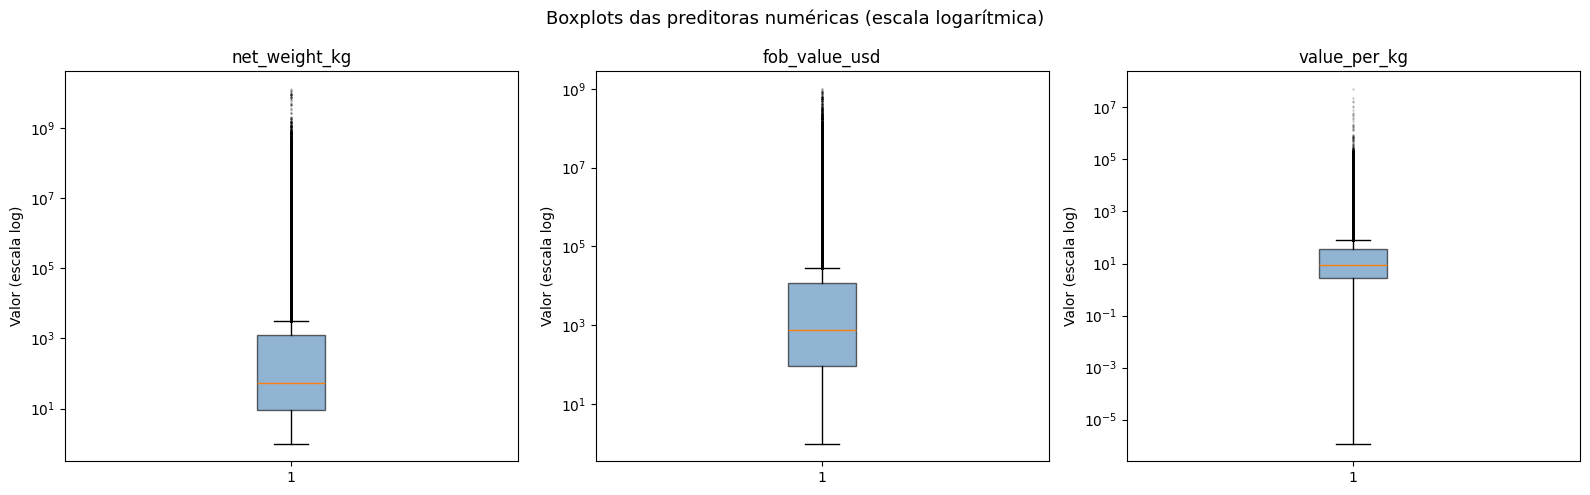

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, numeric_cols):
    data = export_df[col].dropna()
    data = data[data > 0]
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6),
               flierprops=dict(marker=".", markersize=1, alpha=0.3, color="tomato"))
    ax.set_yscale("log")
    ax.set_title(col)
    ax.set_ylabel("Valor (escala log)")

plt.suptitle("Boxplots das preditoras numéricas (escala logarítmica)", fontsize=13)
plt.tight_layout()
plt.show()

In [60]:
# Verifica se outliers se distribuem de forma uniforme entre as vias de transporte
# ou se estão concentrados em rotas específicas (o que indicaria que são sinal, não ruído)

for col in ["net_weight_kg", "fob_value_usd"]:
    series = export_df[col]
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    upper = Q3 + 1.5 * (Q3 - Q1)

    mask = series > upper
    dist = (
        export_df.loc[mask, "transport_route"]
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
        .rename("% dos outliers")
        .reset_index()
        .rename(columns={"index": "transport_route"})
    )
    print(f"\nDistribuição dos outliers de '{col}' por via de transporte:")
    print(dist.to_string(index=False))


Distribuição dos outliers de 'net_weight_kg' por via de transporte:
transport_route  % dos outliers
              1            66.6
              7            27.3
              4             5.2
             15             0.4
              0             0.4
              6             0.1
              3             0.0
              2             0.0
              9             0.0
             12             0.0

Distribuição dos outliers de 'fob_value_usd' por via de transporte:
transport_route  % dos outliers
              1            62.4
              7            23.2
              4            13.6
              0             0.4
             15             0.1
              6             0.1
             12             0.0
              2             0.0
              3             0.0
              9             0.0
              8             0.0


Cerca de 19% dos registros apresentam valores extremos em `net_weight_kg` e 18% em `fob_value_usd`. A concentração nas vias marítima (1) e fluvial (7) indica que são sinal estrutural - o tratamento será definido na etapa de modelagem.

## Merge

Integração do dataset de exportações com as tabelas auxiliares de NCM (produtos) e países, via left join

In [61]:
# Integração com NCM
export_df = export_df.merge(
    ncm_df,
    on="ncm_code",
    how="left"
)

# Integração com países
export_df = export_df.merge(
    countries_df,
    on="country_code",
    how="left"
)

In [62]:
export_df[[
    "ncm_name_ptbr",
    "country_name"
]].isnull().sum()

ncm_name_ptbr    0
country_name     0
dtype: int64

A validação do merge mostrou que todos os registros do dataset principal encontraram correspondência nos datasets auxiliares de NCM e países. Isso indica consistência entre as bases integradas e ausência de perda de informação durante o processo de junção.

In [63]:
export_df = export_df.rename(columns={
    "statistical_quantity_x": "statistical_quantity_export",
    "statistical_quantity_y": "statistical_quantity_ncm"
})

## Exportação do Dataset Limpo

In [64]:
import os
os.makedirs("../results", exist_ok=True)
export_df.to_csv("../results/cleaned_exports_2025.csv", index=False)
print(f"Dataset salvo: {export_df.shape[0]} linhas, {export_df.shape[1]} colunas")
export_df.dtypes

Dataset salvo: 1709746 linhas, 23 colunas


year                               str
month                            int64
ncm_code                           str
statistical_quantity_export        str
country_code                       str
origin_state                       str
transport_route                    str
urf_code                           str
statistical_unit_code            int64
net_weight_kg                    int64
fob_value_usd                    int64
month_name                         str
value_per_kg                   float64
quarter                          int64
semester                         int64
origin_region                      str
ncm_chapter                        str
is_mercosul                      int64
is_coastal_state                 int64
is_express_delivery              int64
statistical_quantity_ncm           str
ncm_name_ptbr                      str
country_name                       str
dtype: object

Dataset final exportado como `cleaned_exports_2025.csv` com 1.709.746 registros e 23 atributos, pronto para a análise exploratória.